# Visualisation de données

## Choix du Jeu de données et justification

Pour ce travail, j'ai choisi un jeu de donnée qui concerne la saison 2024-2025 de football en Ligue 1.
J'ai fais ce choix car je suis vraiment fan de football, et cela me permettra de répondre à certaines des questions que je me pose en tant qu'observateur.

## Objectifs de la visualisation

Dans ce compte rendu, nous allons répondre à 3 questions : 

- 1. Quelle est la distribution des buts marqués par match ?
- 2. Y a-t-il un avantage significatif d'être à domicile pour certaines statistiques ?
- 3. Quel à été l'évolution des résultats d'une équipe donnée tout au long de la saison ?


Ces questions nous permettront de manipuler plusieurs type de réprésentation.  
Il y aura une représentation bonus sous forme de carte afin de visualiser les équipes avec le plus de but à domicile et ceux avec le meilleur taux de victoire.

Jeux de données utilisés : 

- "season-2425.csv" [(source)]((https://datahub.io/core/french-ligue-1) "season-2425") : Contient les statistiques des matchs de la saison 2024-2025 de Ligue 1.
- "stadium.csv" (Données réstatistiquestées manuellement) : Contient les données géographique des stades de ligue 1, avec l'équipe qui y joue, la ville où elle se trouve ainsi que le nom du stade. 
  
Pour le bon choix de chaque diagramme, nous prendrons pour référence le livre **Fundamentals Of Data Visualisation**, *Claus O.Wilke*. [source](https://clauswilke.com/dataviz/index.html)

In [4]:
# import des librairies nécessaires à l'analyse tout au long du compte-rendu
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Quelle est la distribution des buts marqués par match ?

Pour analyser la distribution de cette variable quantitative, nous utilisons un histogramme.

Selon le chapitre 7 du livre de référence, [(7.1 Visualizing a single distribution)](https://clauswilke.com/dataviz/histograms-density-plots.html#multiple-histograms-densities:~:text=of%20the%20passengers.-,7.1%20Visualizing%20a%20single%20distribution,-We%20can%20obtain), l'histogramme est le standard pour visualiser la distribution d'une variable unique. Il permet d'identifier immédiatement la "forme" des données (asymétrie, tendance centrale) et offre une comparaison nette du nombre d'occurrences pour chaque nombre de buts.

### Préparation des données

Afin de calculer le nombre total de buts par rencontre, nous avons dû agréger les données du fichier `season-2324.csv` :

Somme des buts de l'équipe à domicile (FTHG) et de l'équipe à l'extérieur (FTAG).

Création d'une nouvelle colonne Total Goals dans notre DataFrame pour faciliter le traçage.

In [5]:
ligue1 = pd.read_csv("data/season-2324.csv") # chargement du dataframe

# Pour compter le nombre de buts par matchs, il faut additionner les but Domicile (FTHG) et Extérieur (FTAG)
totalGoals = ligue1["FTHG"] + ligue1["FTAG"]

# On peut l'ajouter à notre dataFrame
ligue1["Total Goals"] = totalGoals

ligue1 #Afficher notre Data Frame préparé

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Total Goals
0,11/08/23,Nice,Lille,1,1,D,1,0,H,NaN,...,5,13,9,3,3,3,2,0,0,2
1,12/08/23,Marseille,Reims,2,1,H,1,1,D,NaN,...,4,7,16,10,10,1,3,0,0,3
2,12/08/23,Paris SG,Lorient,0,0,D,0,0,D,NaN,...,0,8,6,9,2,0,0,0,0,0
3,13/08/23,Brest,Lens,3,2,H,1,2,A,NaN,...,2,13,15,6,8,2,3,0,1,5
4,13/08/23,Clermont,Monaco,2,4,A,1,2,A,NaN,...,8,7,16,6,2,0,4,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,19/05/24,Lyon,Strasbourg,2,1,H,1,0,H,NaN,...,4,7,10,7,2,1,0,0,0,3
302,19/05/24,Metz,Paris SG,0,2,A,0,2,A,NaN,...,8,6,9,1,11,2,1,0,0,2
303,19/05/24,Monaco,Nantes,4,0,H,3,0,H,NaN,...,3,14,23,2,2,1,2,0,0,4
304,19/05/24,Reims,Rennes,2,1,H,0,0,D,NaN,...,5,11,17,2,4,1,1,0,0,3


### Visualisation des données

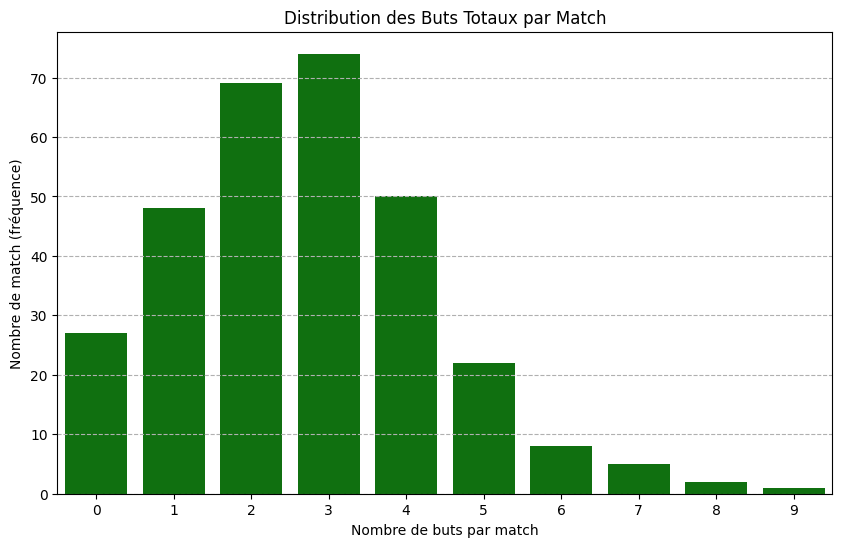

In [6]:
# Préparer la figure
plt.figure(figsize=(10, 6))
plt.title('Distribution des Buts Totaux par Match')
plt.xlabel("Nombre de buts par match")
plt.ylabel("Nombre de match (fréquence)")
plt.grid(axis='y', linestyle='--')

# Représenter les données 
sns.countplot(
    data=ligue1, 
    x='Total Goals', 
    color='Green'
)

plt.show()

### Interprétation des résultats

Cette figure nous montre la distribution du nombre de but, c'est à dire le nombre de match dans lequel il y a eu 0,1,2,3 ... buts. 

La fréquence des matchs est représentée par la hauteur/longueur des barres et le nombre de buts par une barre.

L'efficacité de ce graphique repose sur l'encodage de la fréquence par la longueur (hauteur) de la barre.  
Cette représentation nous permet une comparaison rapide et fiable des différents totaux de buts (ex : déterminer instantanément si les matchs à 2 buts sont plus fréquents que ceux à 3 buts).

Ainsi, que nous apprends cette analyse ? 

- Nous pouvons voir qu'au maximum, dans un match, il y a eu 8 buts marqués.
- Le plus souvent (dans un peu plus de 80 matchs) il y a eu 2 buts par matchs.

## 2. Y a-t-il un avantage significatif d'être à domicile pour certaines statistiques ?

Pour comparer les performances entre le jeu à domicile et à l'extérieur, nous utilisons un diagramme en barres groupé pour visualiser une distribution multiple. 
 
Selon le chapitre 6 du livre de référence, [(6.2 Grouped and stacked bars)](https://clauswilke.com/dataviz/visualizing-amounts.html#:~:text=descending%20data%20values.-,6.2%20Grouped%20and%20stacked%20bars,-All%20examples%20from), ce type de graphique est le cohérent pour visualiser la valeurs de plusieurs variables à la fois car cela permet de mettre en évidence non seulement la moyenne (ou médiane) des statistiques (buts, tirs, corners), mais aussi leur variabilité selon le lieu du match.


### Préparation des données

Pour cette visualisation nous allons nous limiter aux statistiques qui montrent une domination d'une équipe par rapport à l'autre : les buts marqués, le nombre de tirs, et le nombre de corners.  
Ces statistiques nous aideront à mettre en évidence s'il y a un avantage à être à domicile ou pas.

In [7]:
#Selectionner les colonnes pertinentes

statistiques = ligue1[['FTHG', 'FTAG', 'HS', 'AS', 'HC', 'AC']]

# Renommer les colonnes temporairement pour identifier plus facilement
statistiques.columns = [
    'But_Domicile', 'But_Exterieur', 
    'Tir_Domicile', 'Tir_Exterieur', 
    'Corners_Domicile', 'Corners_Exterieur'
]

# Utiliser melt pour transformer le DataFrame en format qui facilite l'affichage
comparaison = statistiques.melt(
    value_vars=[
        'But_Domicile', 'But_Exterieur', 
        'Tir_Domicile', 'Tir_Exterieur', 
        'Corners_Domicile', 'Corners_Exterieur'
    ],
    var_name='stat', # Le nom de la statistique
    value_name='valeurStat' # Colonne qui contiendra les chiffres
)

# Séparer la colonne 'stat' en deux colonnes distinctes
comparaison[['stat', 'Equipe']] = comparaison['stat'].str.split('_', expand=True)

# Garder seulement les colonnes nécessaires
comparaison = comparaison[['stat', 'Equipe', 'valeurStat']]

comparaison # Afficher notre data frame préparé

,stat,Equipe,valeurStat
0,But,Domicile,1
1,But,Domicile,2
2,But,Domicile,0
3,But,Domicile,3
4,But,Domicile,2
...,...,...,...
1831,Corners,Exterieur,2
1832,Corners,Exterieur,11
1833,Corners,Exterieur,2
1834,Corners,Exterieur,4


### Visualisation des données

C:\Users\payet.RUDY_STRIX\AppData\Local\Temp\ipykernel_22292\2793022178.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Equipe", loc='upper left')


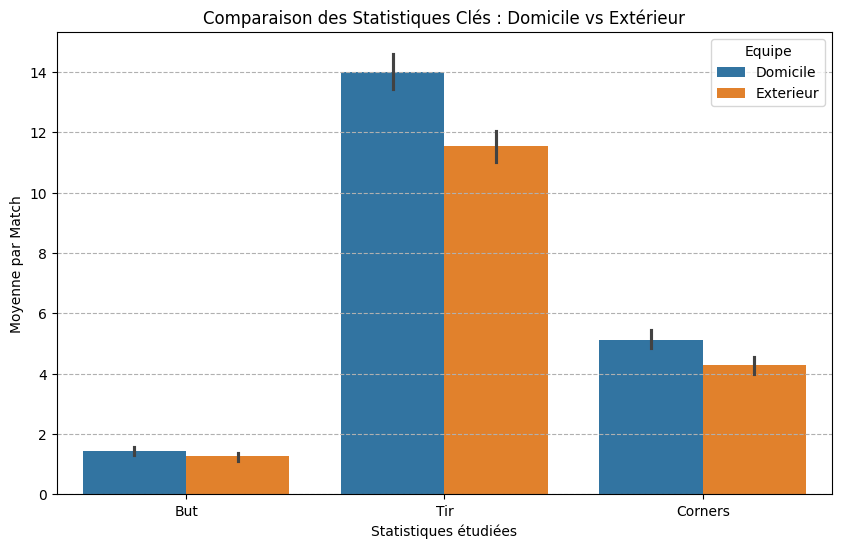

In [8]:
# Préparer la figure
plt.figure(figsize=(10, 6))

plt.title("Comparaison des Statistiques Clés : Domicile vs Extérieur")
plt.xlabel("Statistiques étudiées")
plt.ylabel("Moyenne par Match")
plt.legend(title="Equipe", loc='upper left')
plt.grid(axis='y', linestyle='--')

# Représenter les données
sns.barplot(
    data=comparaison,
    x='stat',
    y='valeurStat',
    hue='Equipe' # C'est ce qui crée le groupement (la catégorie de comparaison)
)

plt.show()

### Interprétation des résultats

Cette figure nous montre la différence de statistique de domination (buts, tirs, corners) entre les équipes à domicile et celles à l'extérieur.

Chaque statistique est directement comparée entre les deux camp (Domicile/Extérieur).  
La hauteur des barres représentent la moyenne pour chaque statistique pour chacun des camps.  
Une marge d'incertitude apparait. C'est important car cela permet de nuancer l'analyse [(16 Visualizing uncertainty)](https://clauswilke.com/dataviz/visualizing-uncertainty.html#:~:text=of%20Data%20Visualization-,16%20Visualizing%20uncertainty,-One%20of%20the).

L'efficacité de ce graphique repose sur la comparaison directe d'une même statistique entre deux (ou plusieurs) variables.  
Cette représentation permet de voir directement si être à domicile procure un certain avantage dans ces différentes statistique.

Qu'apprenons nous de cette analyse ? 

- On observe que pour chacune des 3 statistiques, le fait d'être à domicile permet de mieux performer.
- La marge d'erreur nous indique que :
  - Pour les buts : léger chevauchement, l'avantage à domicile est probable, mais la différence n'est pas considérée comme statistiquement significative ;
  - Pour les tirs : pas de cheuvauchement, l'avantage à domicile est statistiquement significatif à un niveau élevé ;
  - Pour les corners : léger chevauchement, l'avantage à domicile est probable, mais la différence n'est pas considérée comme statistiquement significative.

## 3. Quel à été l'évolution des résultats d'une équipe donnée tout au long de la saison ?

**Choix de la visualisation**

Pour répondre à cette question, nous utilisons un graphique à points alignés (dot plot) sur une échelle temporelle (par journée de championnat).

Selon les principes de visualisation, ce type de représentation est idéal pour observer des séquences ou des séries temporelles de données catégorielles (Victoire, Nul, Défaite). L'utilisation d'un code couleur distinct (palette palette_resultats) permet d'identifier immédiatement les dynamiques de l'équipe (séries de victoires ou périodes de méforme).

### Préparation des données

L'analyse nécessite de filtrer le jeu de données pour une équipe spécifique (définie par la variable EQUIPE_CIBLE). Nous devons extraire :

La journée du match.

Le résultat du point de vue de l'équipe choisie (en comparant les buts marqués et encaissés à domicile ou à l'extérieur).

### Visualisation des données

In [9]:
EQUIPE_CIBLE = 'Marseille' # Equipe que l'on veut représenter la saison

# Filtrer les matchs impliquant l'équipe cible
team_games = ligue1[(ligue1['HomeTeam'] == EQUIPE_CIBLE) | (ligue1['AwayTeam'] == EQUIPE_CIBLE)].copy()

# Déterminer le résultat (Victoire/Nul/Défaite) du match du point de vue de l'équipe cible
def get_team_result(match, team):
    """Détermine si le résultat FTR est une Victoire (W), un Nul (D) ou une Défaite (L) pour l'équipe cible."""
    
    # L'équipe cible joue à Domicile
    if match['HomeTeam'] == team:
        if match['FTR'] == 'H':
            return 'Win'
        elif match['FTR'] == 'D':
            return 'Draw'
        else:
            return 'Loss'
    
    # L'équipe cible joue à l'Extérieur
    elif match['AwayTeam'] == team:
        if match['FTR'] == 'A':
            return 'Win'
        elif match['FTR'] == 'D':
            return 'Draw'
        else:
            return 'Loss'
        
# Récupération des résultats
resultats = []

for index, row in team_games.iterrows():
    resultat = get_team_result(row, EQUIPE_CIBLE)
    resultats.append(resultat)
team_games['Resultat_Team'] = resultats

# Créer la variable séquentielle Journée
team_games['Journee'] = range(1, len(team_games) + 1)

team_games[['Journee', 'HomeTeam', 'AwayTeam', 'FTR', 'Resultat_Team']]

,Journee,HomeTeam,AwayTeam,FTR,Resultat_Team
1,1,Marseille,Reims,H,Win
9,2,Metz,Marseille,D,Draw
19,3,Marseille,Brest,H,Win
27,4,Nantes,Marseille,D,Draw
43,5,Marseille,Toulouse,D,Draw
52,6,Paris SG,Marseille,H,Loss
56,7,Monaco,Marseille,H,Loss
66,8,Marseille,Le Havre,H,Win
73,9,Nice,Marseille,H,Loss
90,10,Marseille,Lille,D,Draw


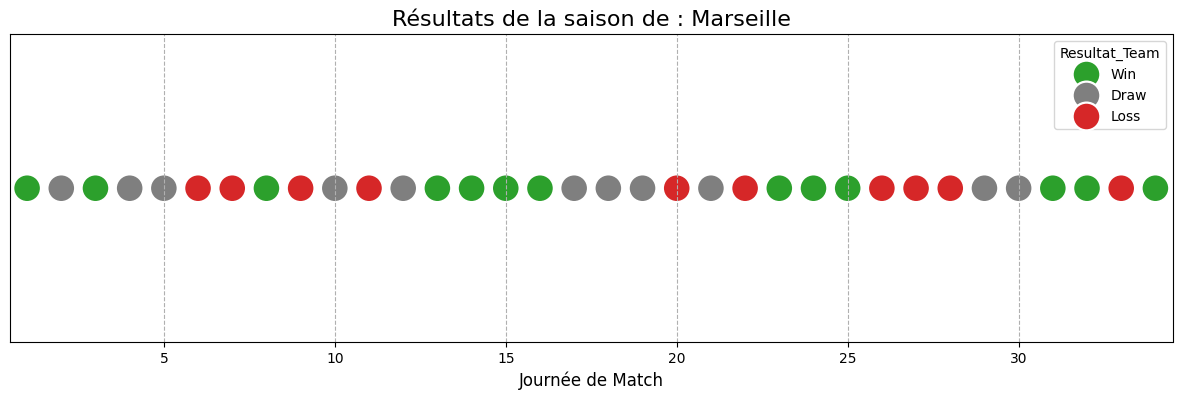

In [10]:
# Palette de couleurs (vert pour gagner, rouge pour perdre, gris pour nul)
palette_resultats = {'Win': '#2ca02c', 'Draw': '#7f7f7f', 'Loss': '#d62728'} 

# Préparer la figure
plt.figure(figsize=(15, 4))
plt.title(f"Résultats de la saison de : {EQUIPE_CIBLE}", fontsize=16)
plt.xlabel("Journée de Match", fontsize=12)
plt.yticks([]) # ne pas afficher les valeurs de l'axe des ordonnées
plt.xlim(0.5, len(team_games) + 0.5) 
plt.grid(axis='x', linestyle='--')

# Représenter les données en nuage de points
sns.scatterplot(
    data=team_games,
    x='Journee',
    y=0,   # Valeur constante pour aligner le poits horizontalement
    hue='Resultat_Team', 
    s=400, # Taille des points
    palette=palette_resultats
)

plt.show()

## Bonus : Cartographie des victoires à Domicile

**Choix de la visualisation**

Pour cette analyse géographique, nous avons choisi de créer une carte interactive avec la bibliothèque folium.

En nous appuyant sur les principes d'encodage visuel de Claus O. Wilke, nous utilisons des marqueurs circulaires (CircleMarker) qui permettent de croiser deux indicateurs de performance :

- La taille du cercle (Radius) : Elle est proportionnelle au nombre total de buts marqués à domicile. Le volume de buts varie et permet d'identifier visuellement les attaques les plus prolifiques devant leur public. 
- La couleur du cercle : Elle encode le taux de victoire à domicile. Nous avons défini trois seuils pour une lecture immédiate :
  - Vert : Forteresse (Taux de victoire $\ge 50\%$)
  - Orange : Performance équilibrée (Taux entre $35\%$ et $49\%$)
  - Rouge : Difficulté à domicile (Taux $< 35\%$)

### Préparation des données

L'élaboration de cette carte a nécessité une préparation de données en plusieurs étapes :

Calcul des statistiques par club (nombre de victoires et total des buts marqués à domicile).

Calcul du taux de réussite en pourcentage.

Jointure de données (Merge) : Fusion de nos statistiques avec le fichier externe stadium.csv pour récupérer les coordonnées géographiques (Latitude/Longitude) et le nom des stades.

Utilisation d'un MarkerCluster pour améliorer la lisibilité de la carte lors de zooms arrières.

### Visualisation

In [11]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# 1. Préparation des statistiques de performance à domicile

stats_home = ligue1.groupby('HomeTeam').agg(
    HomeGoals=('FTHG', 'sum'),      # Volume de buts (servira pour la taille)
    MatchesPlayed=('FTR', 'count'),  # Nombre de matchs
    HomeWins=('FTR', lambda x: (x == 'H').sum()) # Nombre de victoires
).reset_index()

# Calcul du taux de victoire en % (servira pour la couleur)
stats_home['WinRate'] = (stats_home['HomeWins'] / stats_home['MatchesPlayed'] * 100).round(1)

# 2. Fusion avec les coordonnées géographiques de votre fichier stadium.csv
df_stadiums = pd.read_csv('data/stadium.csv')
df_map = pd.merge(stats_home, df_stadiums, on='HomeTeam')

# 3. Fonction pour définir la couleur selon la performance
def get_color(rate):
    if rate >= 50: return '#2ca02c' # Vert (Forteresse)
    elif rate >= 35: return '#ff7f0e' # Orange (Moyen)
    else: return '#d62728'           # Rouge (Faible)

# 4. Création de la carte centrée sur la France
m = folium.Map(location=[46.2276, 2.2137], zoom_start=6, tiles='cartodbpositron')
marker_cluster = MarkerCluster().add_to(m)

# 5. Ajout des cercles sur la carte
for index, row in df_map.iterrows():
    color_code = get_color(row['WinRate'])
    # La taille du cercle dépend du nombre de buts marqués
    circle_radius = row['HomeGoals'] * 0.7 
    
    # Texte de l'infobulle (Popup)
    popup_content = f"""
    <div style='font-family: Arial; width: 180px;'>
        <h4 style='margin-bottom:5px;'>{row['HomeTeam']}</h4>
        <b>Stade :</b> {row['Stade']}<br>
        <b>Buts marqués :</b> {row['HomeGoals']}<br>
        <b>Taux de victoire :</b> {row['WinRate']}%
    </div>
    """
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=circle_radius,
        popup=folium.Popup(popup_content, max_width=300),
        color=color_code,
        fill=True,
        fill_color=color_code,
        fill_opacity=0.7
    ).add_to(marker_cluster)

# Affichage de la carte
m

### Interprétation des résultats

Cette visualisation permet de distinguer deux types de domination.  
Par exemple, un grand cercle orange indique une équipe très offensive qui marque beaucoup de buts, mais qui ne parvient pas toujours à transformer ce spectacle en victoires systématiques.  
À l'inverse, un cercle plus petit mais vert révèle une équipe très efficace et pragmatique, capable de gagner ses matchs avec un nombre restreint de buts. 

Cette approche cartographique offre une dimension spatiale aux statistiques, montrant si certaines régions géographiques bénéficient d'une ferveur à domicile plus marquée.